Summary of findings:

1. Interesting Temperature pattern (noise increases in new ESI-CorA project, before, there was a very clear pattern)
2. Nothing else stood out as interesting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../../data/preprocessed/wastewater.csv")
df.Date = pd.to_datetime(df.Date)

In [3]:
df.head()

,Sampling_Area,Date,Avg_FlowRate,COVID_N1,COVID_N2,PMMoV,Temperature,Bemerkung,Project,bestimmungsgrenze,precipitation_event,flow_normalized_COVID_N1,flow_normalized_COVID_N2,PMMoV_normalized_COVID_N1,PMMoV_normalized_COVID_N2
0,South,2022-02-28,440.960648,5754.242558,3463.697591,5.426348e+06,11.80,3.46369759101506,ESI_CorA,False,dry,8083.334228,4865.666507,40943.383562,24645.380791
1,North,2022-03-02,454.606481,69802.087396,32133.554283,5.212840e+07,12.00,NaN,ESI_CorA,False,dry,101089.621573,46536.843860,51700.801303,23800.584869
2,South,2022-03-02,454.606481,11913.284794,8173.140016,7.364685e+06,15.60,NaN,ESI_CorA,False,dry,17253.201107,11836.603490,62456.923001,42848.734456
3,North,2022-03-07,446.041667,71179.149700,22482.965460,4.268556e+07,13.05,NaN,ESI_CorA,False,dry,101141.819665,31947.108776,64383.569621,20336.483058
4,South,2022-03-07,446.041667,17522.583462,10906.017579,8.340562e+06,14.38,NaN,ESI_CorA,False,dry,24898.667434,15496.876092,81115.907111,50486.362972


In [4]:
df.columns

Index(['Sampling_Area', 'Date', 'Avg_FlowRate', 'COVID_N1', 'COVID_N2',
       'PMMoV', 'Temperature', 'Bemerkung', 'Project', 'bestimmungsgrenze',
       'precipitation_event', 'flow_normalized_COVID_N1',
       'flow_normalized_COVID_N2', 'PMMoV_normalized_COVID_N1',
       'PMMoV_normalized_COVID_N2'],
      dtype='object')

Avg_FlowRate
 



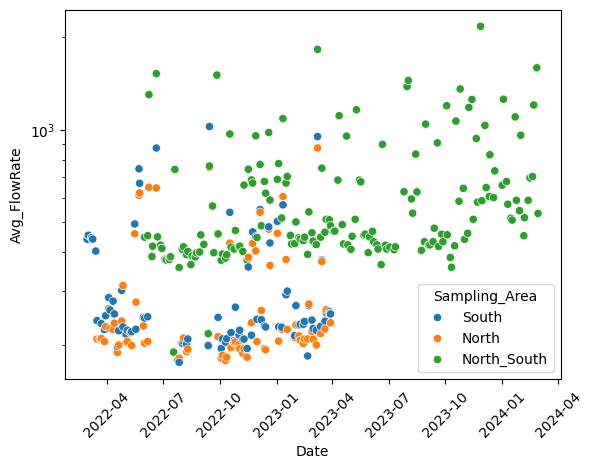

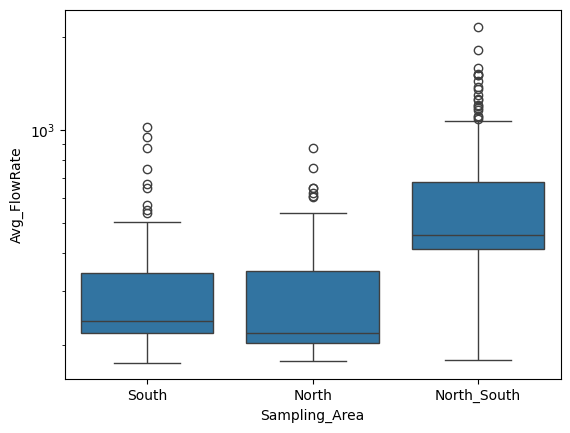

COVID_N1
 



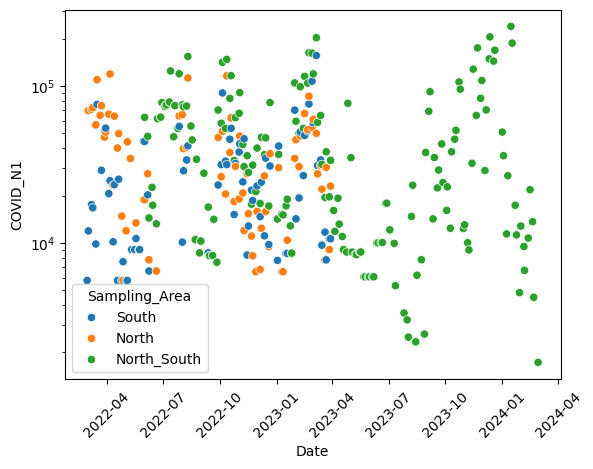

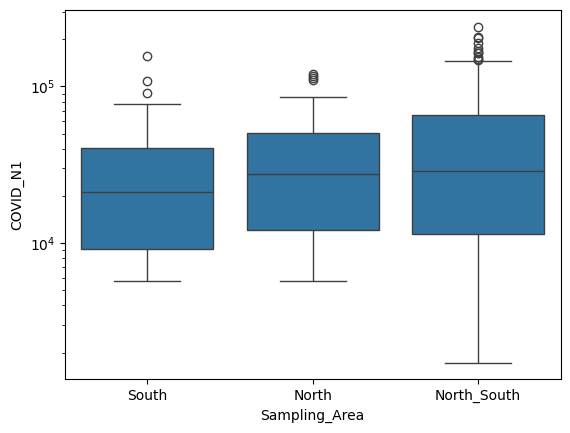

COVID_N2
 



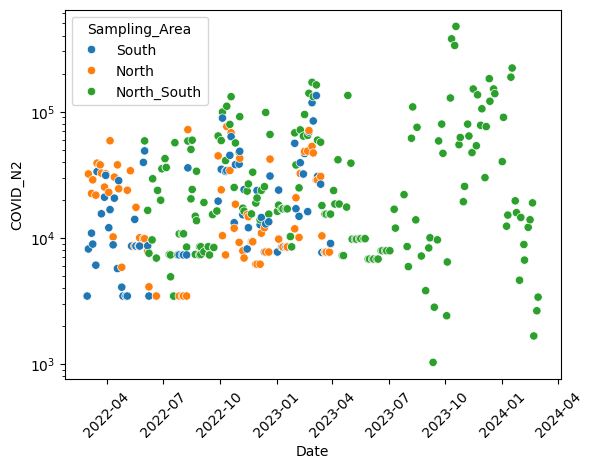

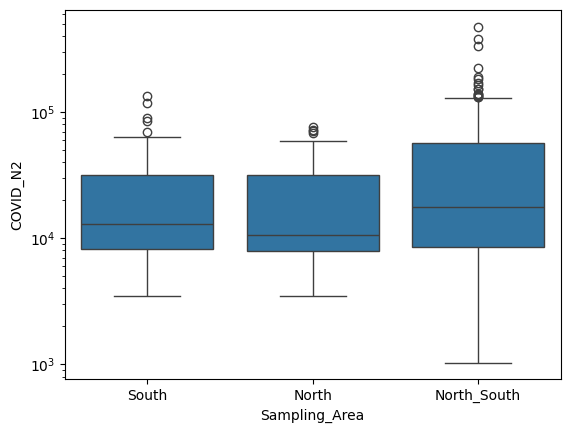

PMMoV
 



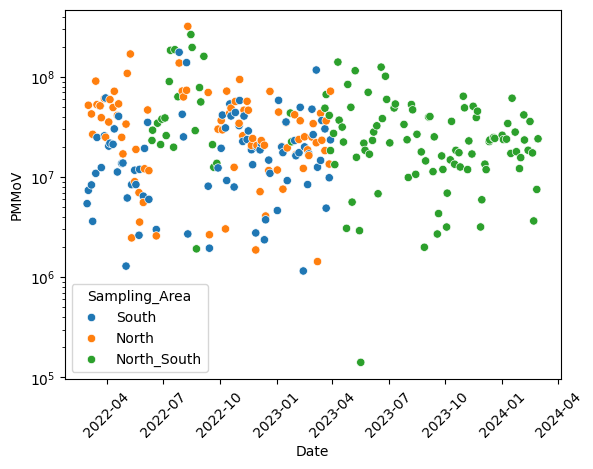

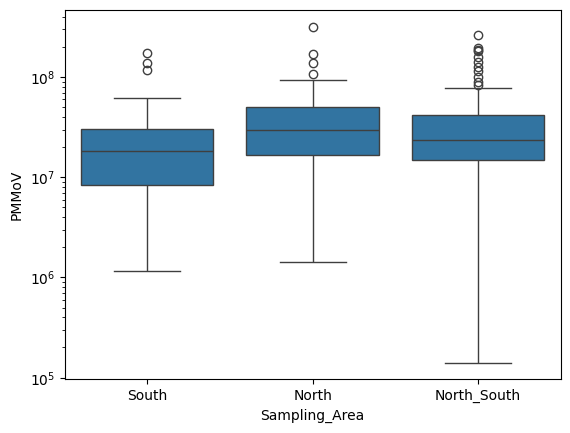

flow_normalized_COVID_N1
 



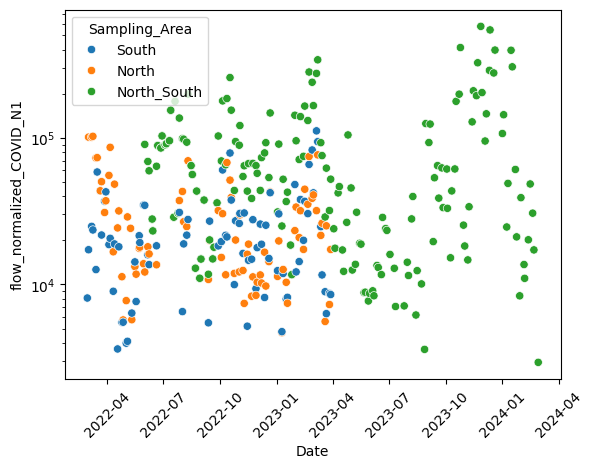

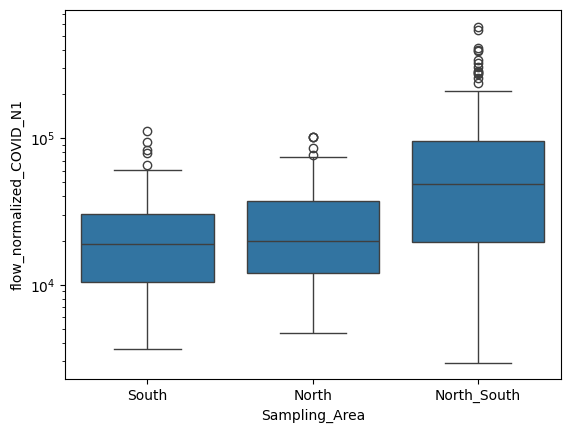

flow_normalized_COVID_N2
 



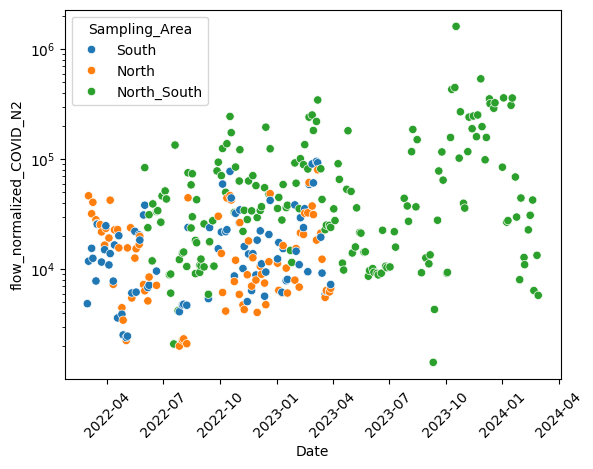

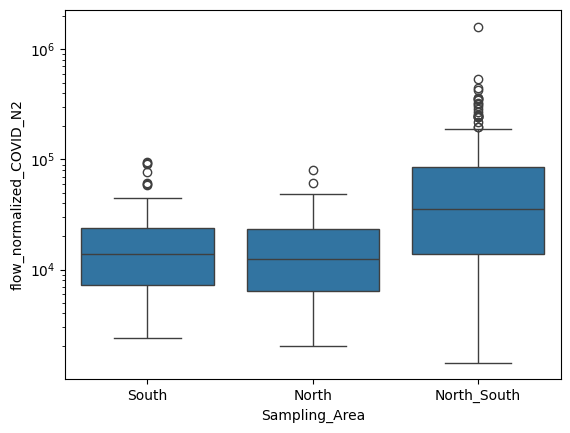

PMMoV_normalized_COVID_N1
 



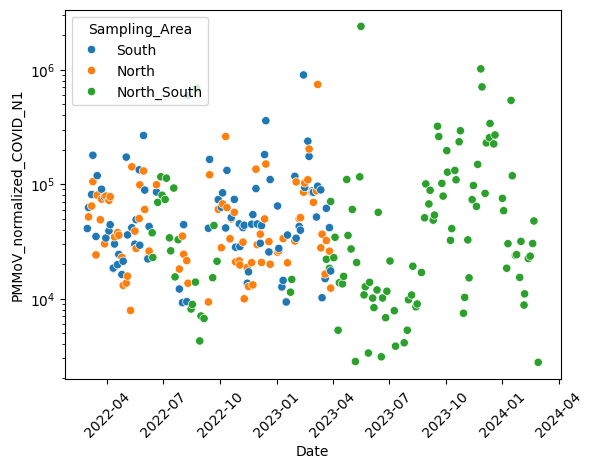

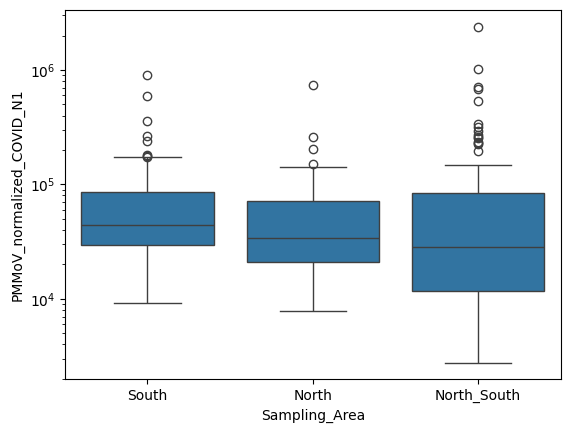

PMMoV_normalized_COVID_N2
 



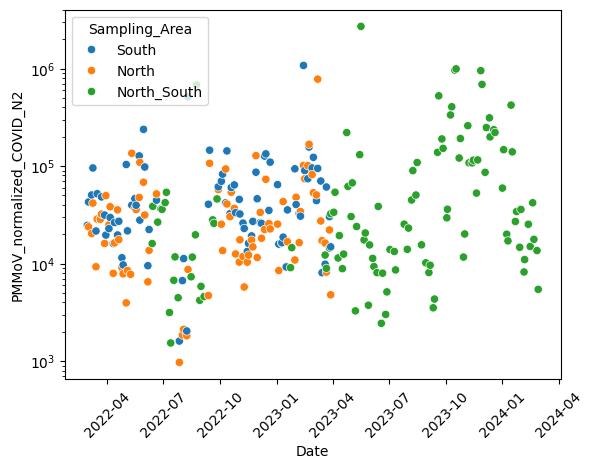

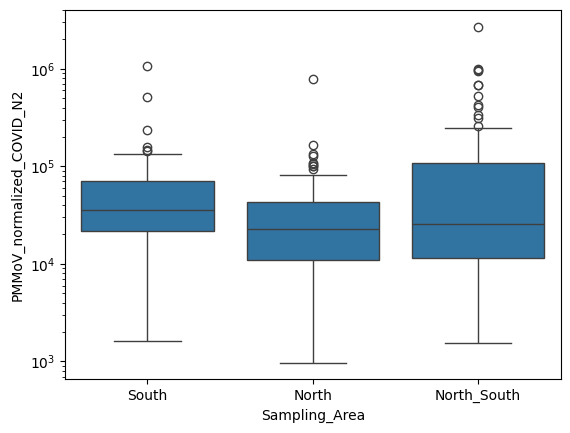

Temperature
 



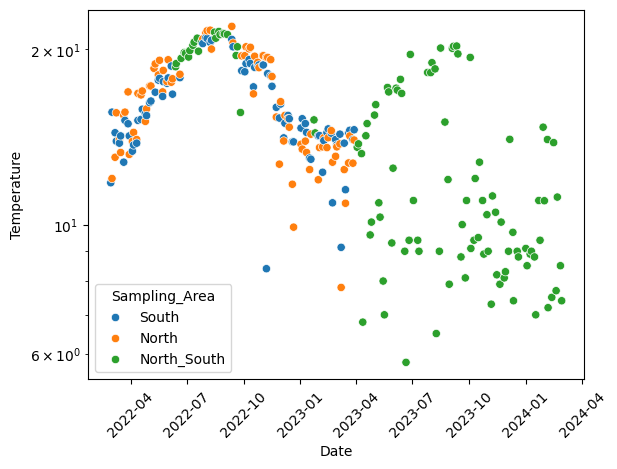

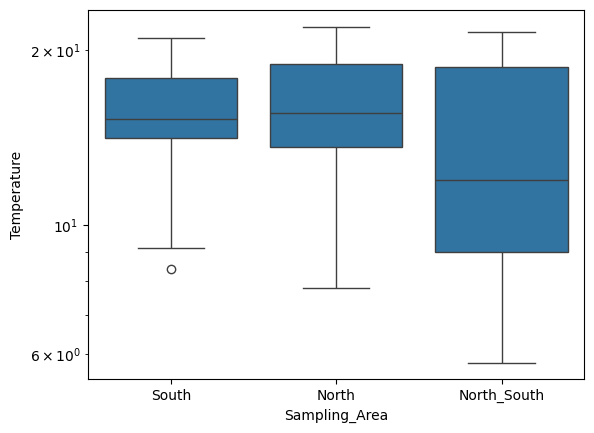

In [50]:
for var in ['Avg_FlowRate', 'COVID_N1', 'COVID_N2',
       'PMMoV', 'flow_normalized_COVID_N1',
       'flow_normalized_COVID_N2', 'PMMoV_normalized_COVID_N1',
       'PMMoV_normalized_COVID_N2', "Temperature"]:
    print(var+"\n \n")

    sns.scatterplot(data=df, x="Date", y=var, hue="Sampling_Area")
    plt.xticks(rotation=45)  # Rotate x-axis labels by 45 degrees
    plt.yscale("log")  # Set y-axis to log scale
    plt.show()

    sns.boxplot(data=df, x="Sampling_Area", y=var)
    plt.yscale("log")  # Set y-axis to log scale
    plt.show()

### Difference in temperature pattern between AMELAG and ESI_CorA

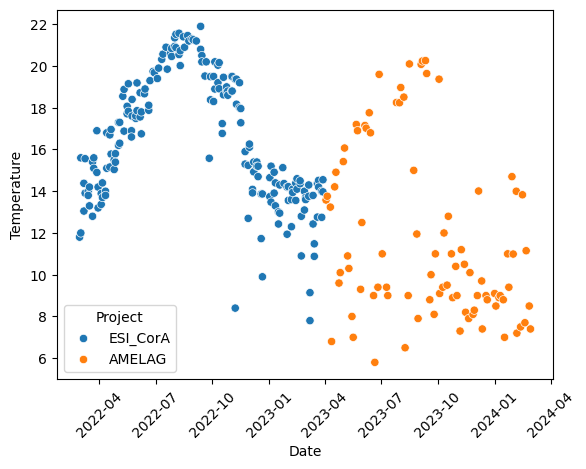

In [5]:
var = "Temperature"
sns.scatterplot(data=df, x="Date", y=var, hue="Project")
plt.xticks(rotation=45)  # Rotate x-axis labels by 45 degrees
plt.show()

In [6]:
df.precipitation_event.value_counts()

precipitation_event
dry           253
light_rain     84
heavy_rain     32
Name: count, dtype: int64

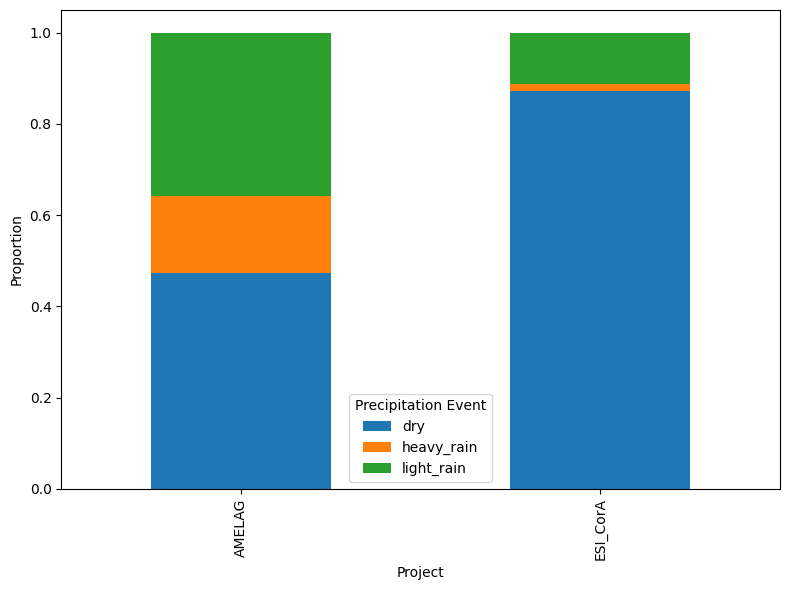

In [14]:
# Group and normalize value counts
grouped =df.groupby("Project")["precipitation_event"].value_counts(normalize=True).unstack()

# Plotting
ax = grouped.plot(kind='bar', stacked=True, figsize=(8, 6))
plt.xlabel("Project")
plt.ylabel("Proportion")
plt.legend(title="Precipitation Event")
plt.tight_layout()
plt.show()

Project   precipitation_event
AMELAG    dry                    0.473988
          light_rain             0.358382
          heavy_rain             0.167630
ESI_CorA  dry                    0.872449
          light_rain             0.112245
          heavy_rain             0.015306
Name: proportion, dtype: float64

### Difference subselected precipitation events

Avg_FlowRate
 



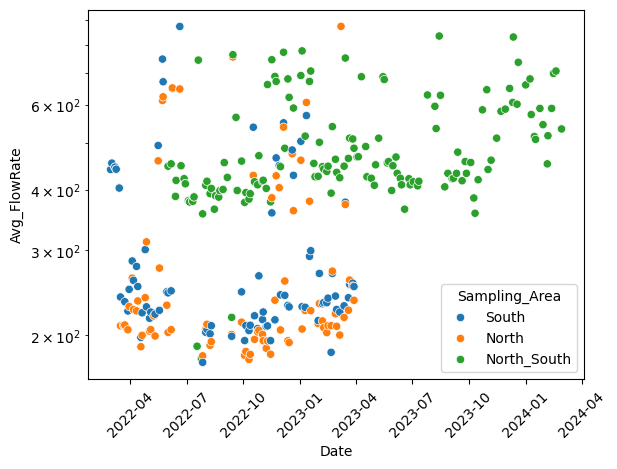

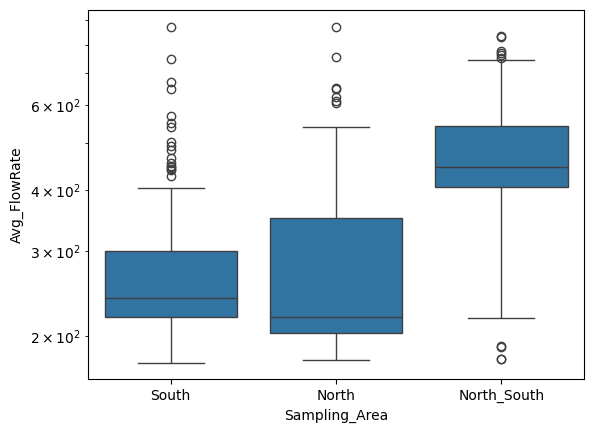

COVID_N1
 



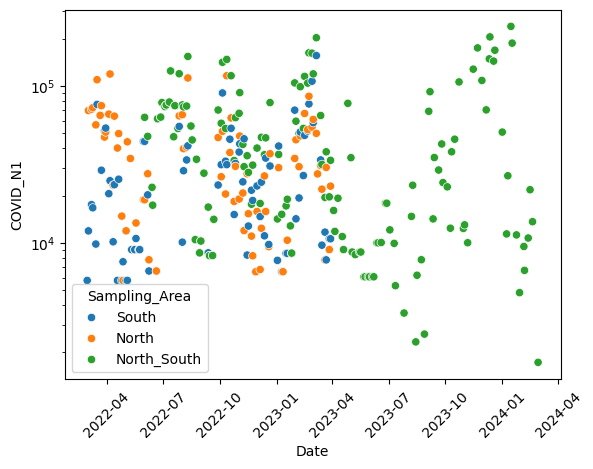

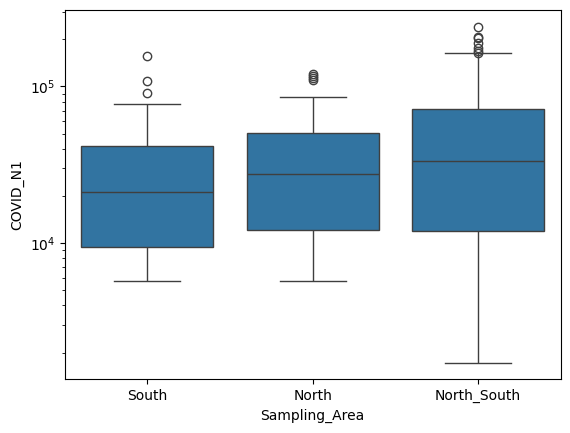

COVID_N2
 



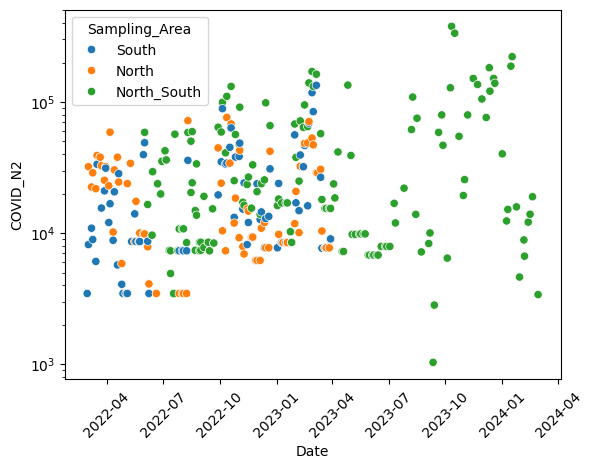

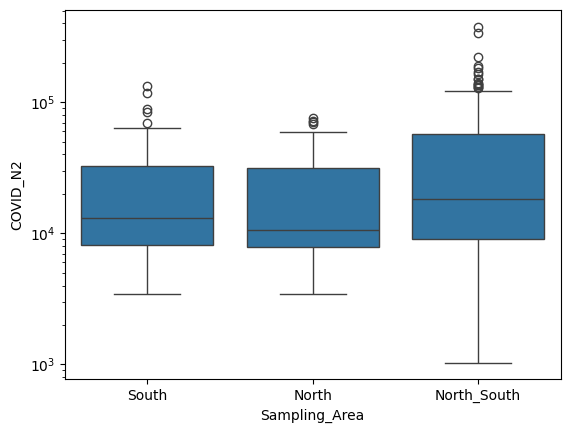

PMMoV
 



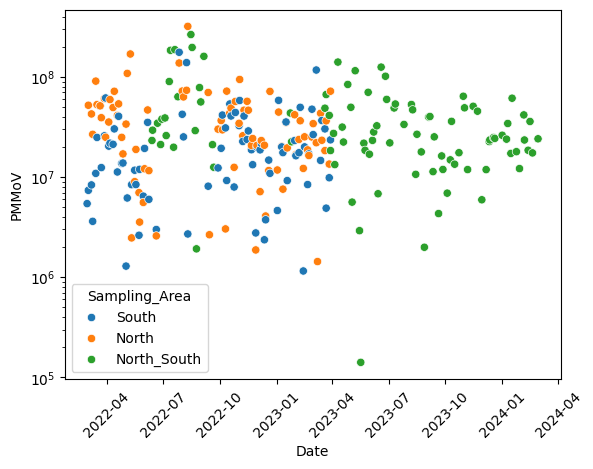

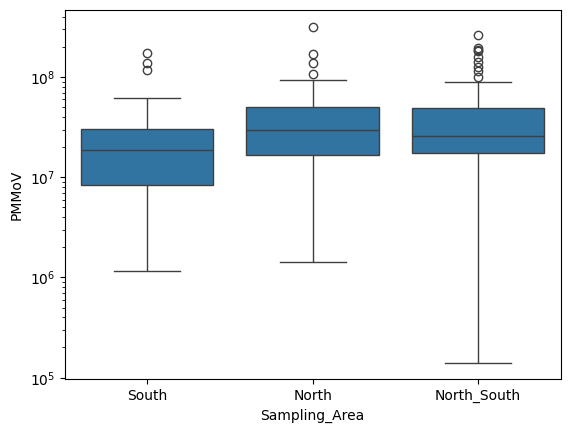

flow_normalized_COVID_N1
 



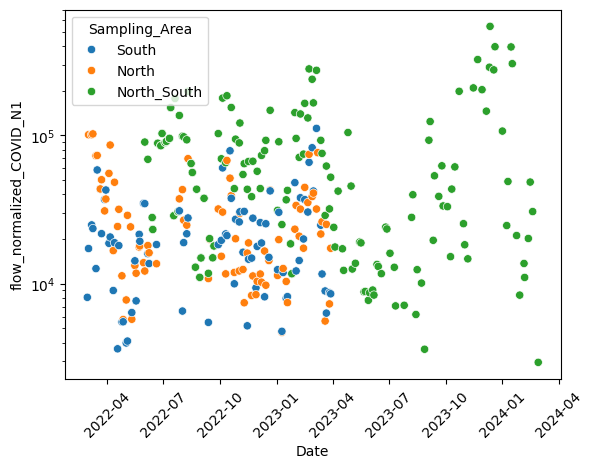

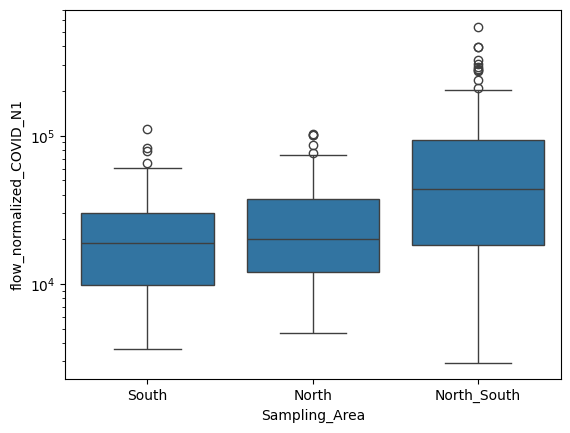

flow_normalized_COVID_N2
 



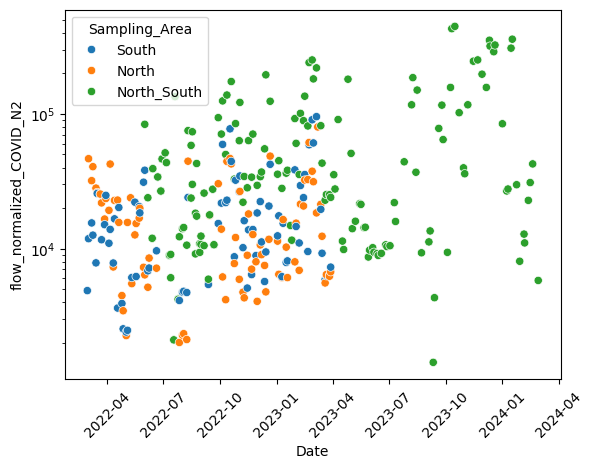

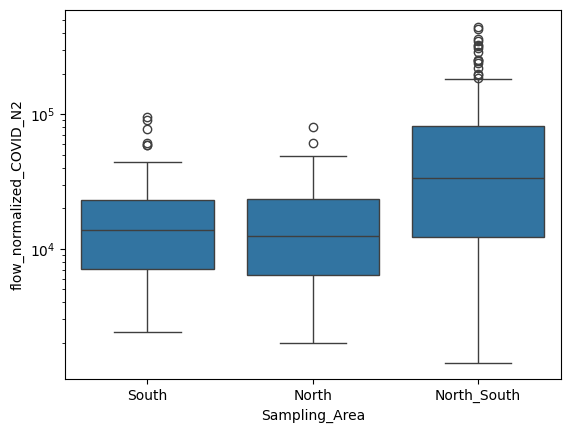

PMMoV_normalized_COVID_N1
 



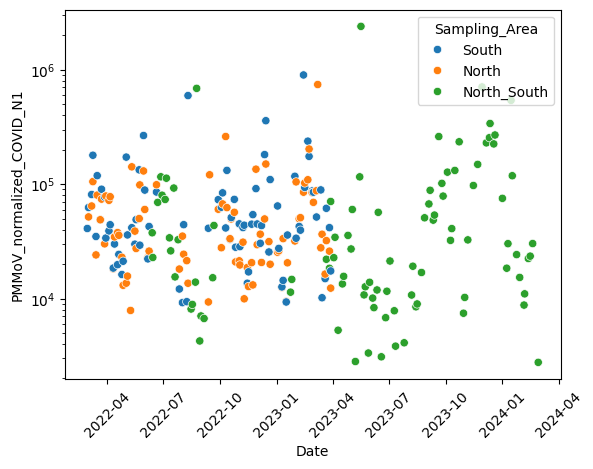

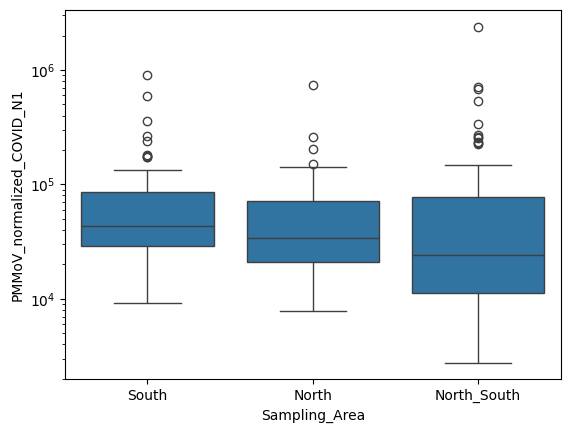

PMMoV_normalized_COVID_N2
 



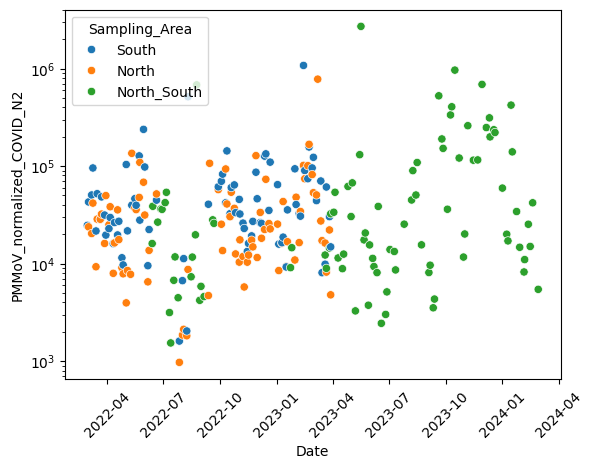

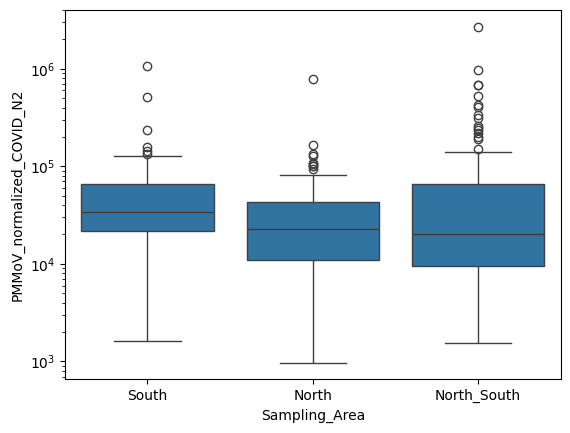

Temperature
 



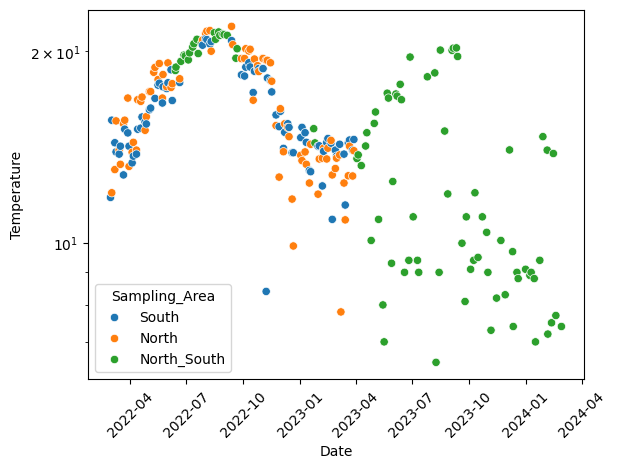

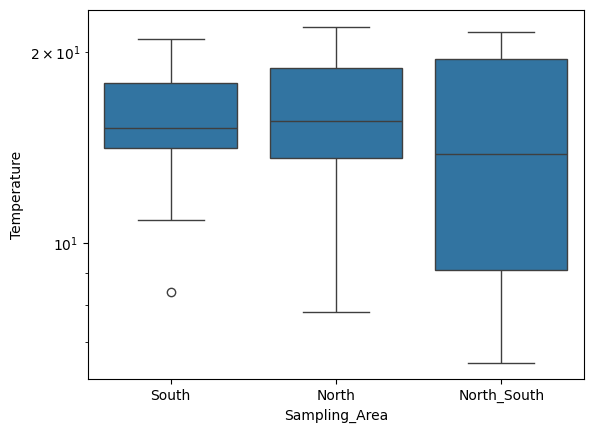

In [53]:
for var in ['Avg_FlowRate', 'COVID_N1', 'COVID_N2',
       'PMMoV', 'flow_normalized_COVID_N1',
       'flow_normalized_COVID_N2', 'PMMoV_normalized_COVID_N1',
       'PMMoV_normalized_COVID_N2', "Temperature"]:
    print(var+"\n \n")

    sns.scatterplot(data=df.loc[df.precipitation_event!="heavy_rain",:], x="Date", y=var, hue="Sampling_Area")
    plt.xticks(rotation=45)  # Rotate x-axis labels by 45 degrees
    plt.yscale("log")  # Set y-axis to log scale
    plt.show()

    sns.boxplot(data=df.loc[df.precipitation_event!="heavy_rain",:], x="Sampling_Area", y=var)
    plt.yscale("log")  # Set y-axis to log scale
    plt.show()

### Comparing precipitation events

Avg_FlowRate
 



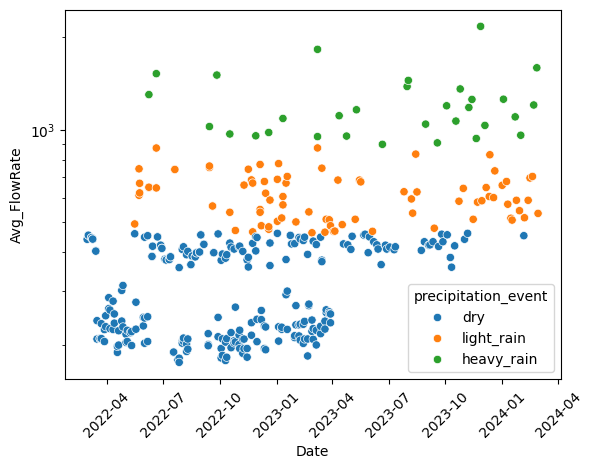

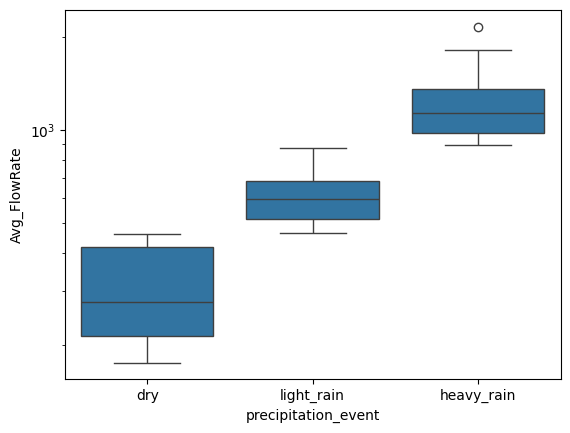

COVID_N1
 



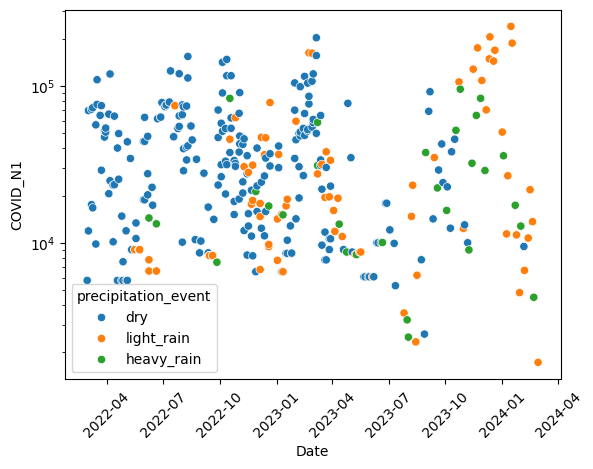

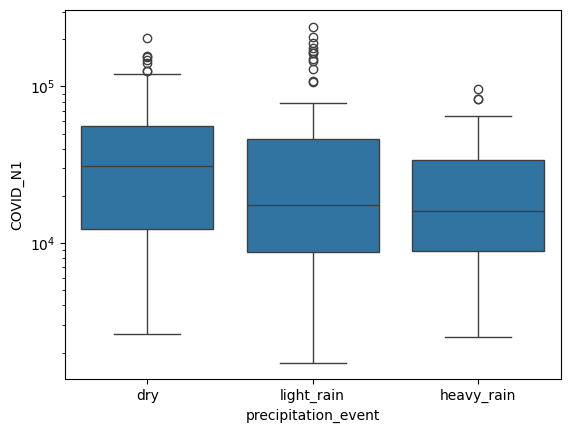

COVID_N2
 



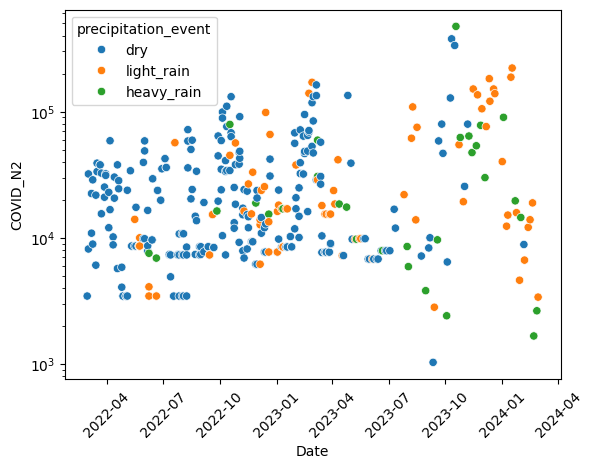

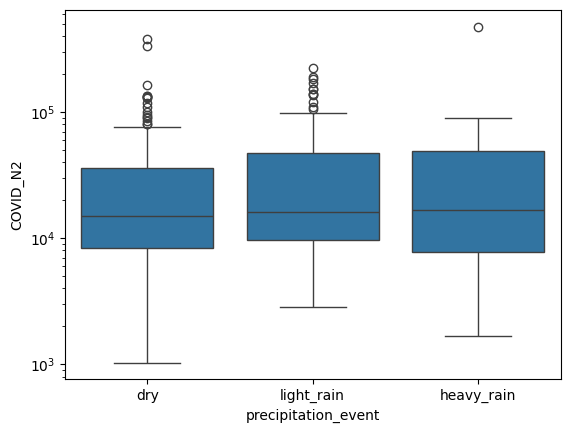

PMMoV
 



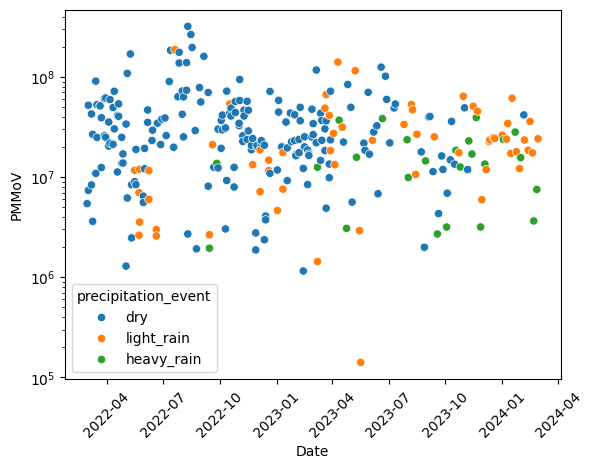

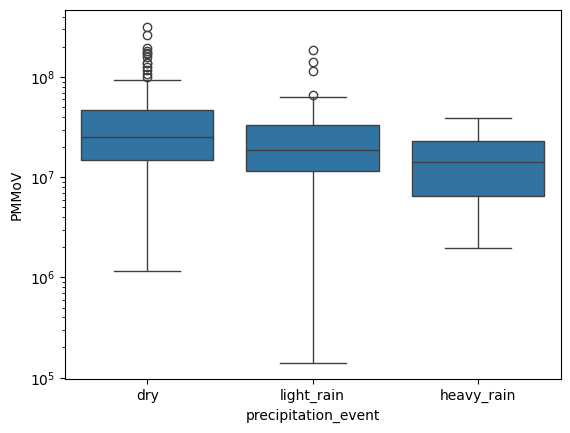

flow_normalized_COVID_N1
 



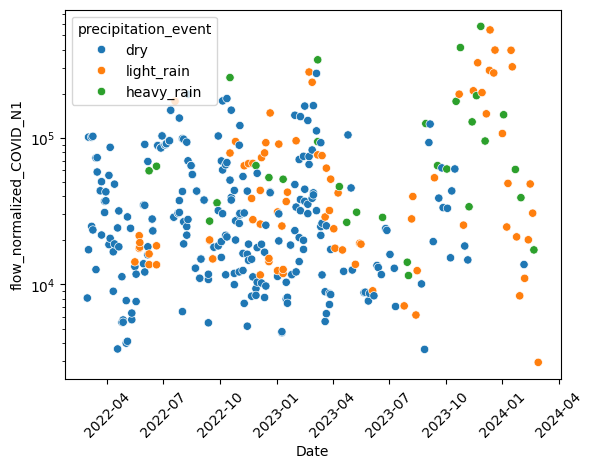

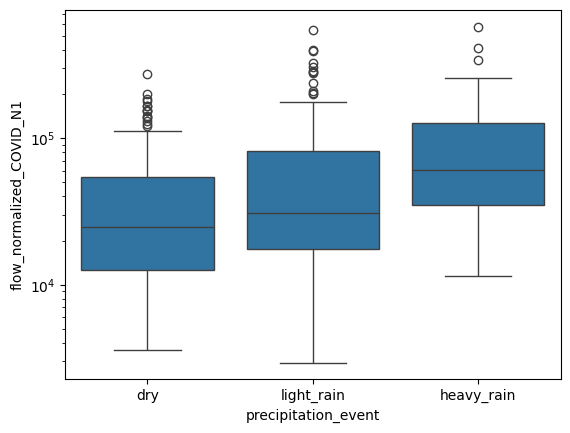

flow_normalized_COVID_N2
 



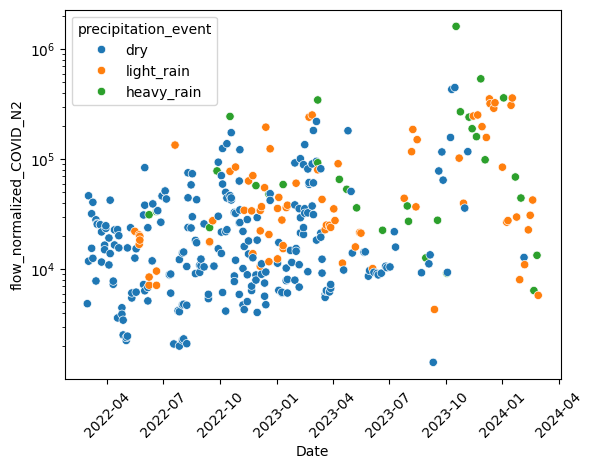

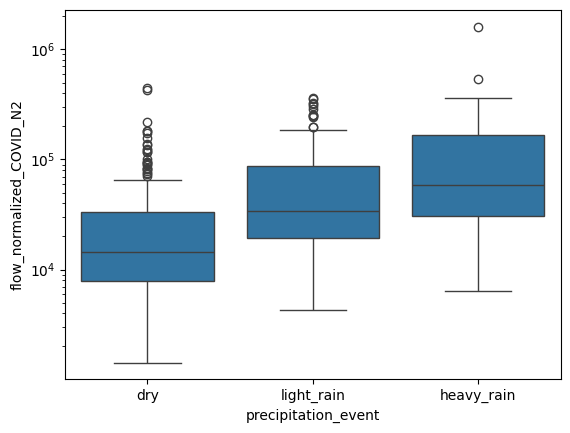

PMMoV_normalized_COVID_N1
 



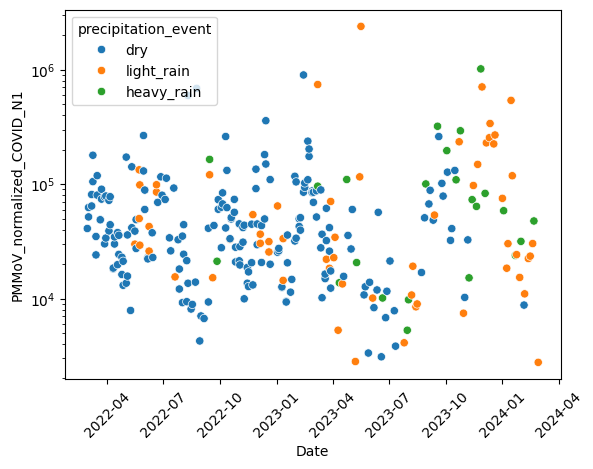

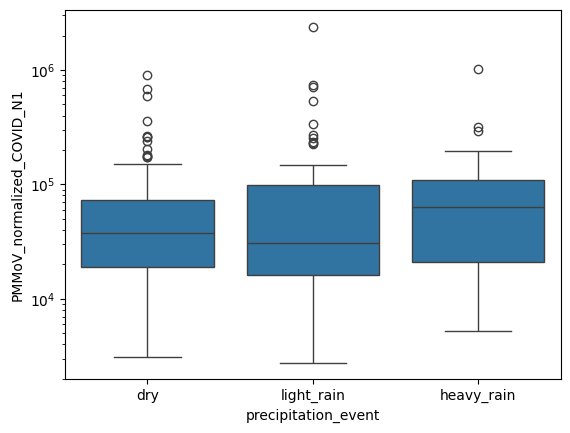

PMMoV_normalized_COVID_N2
 



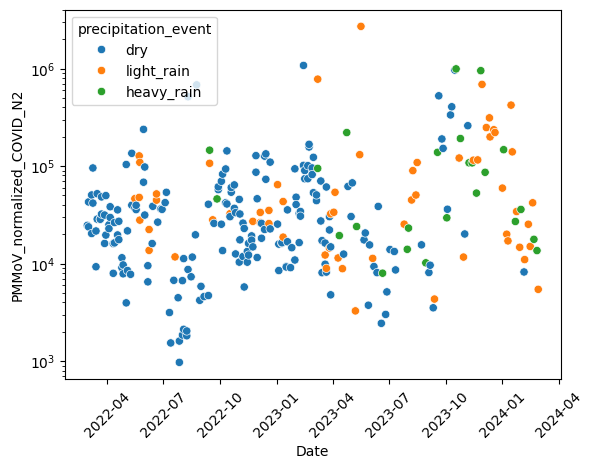

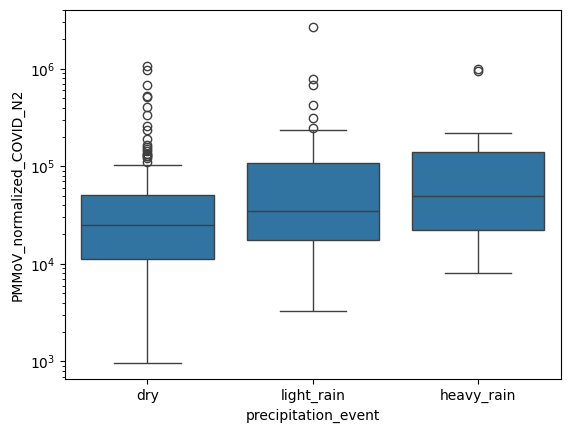

Temperature
 



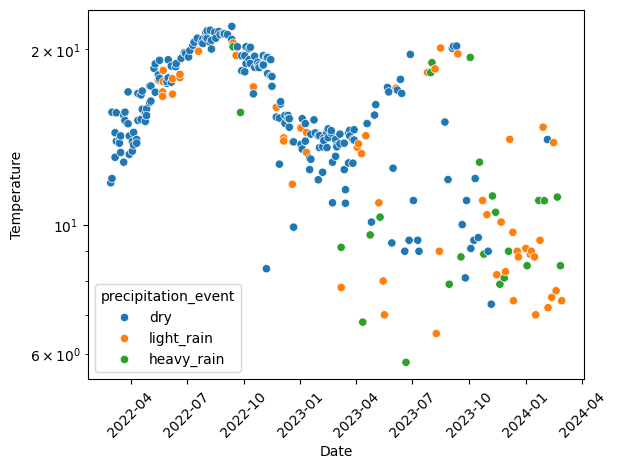

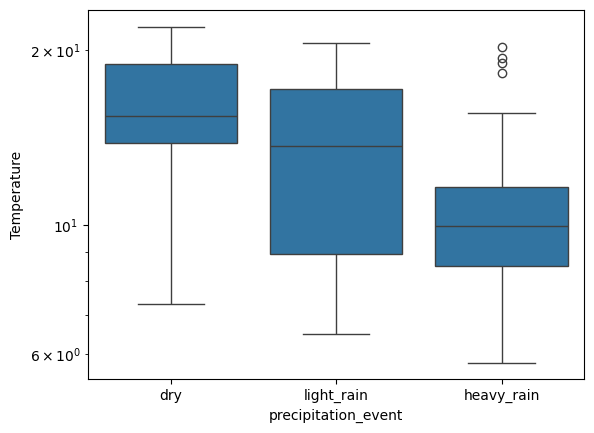

In [59]:
for var in ['Avg_FlowRate', 'COVID_N1', 'COVID_N2',
       'PMMoV', 'flow_normalized_COVID_N1',
       'flow_normalized_COVID_N2', 'PMMoV_normalized_COVID_N1',
       'PMMoV_normalized_COVID_N2', "Temperature"]:
    print(var+"\n \n")

    sns.scatterplot(data=df, x="Date", y=var, hue="precipitation_event")
    plt.xticks(rotation=45)  # Rotate x-axis labels by 45 degrees
    plt.yscale("log")  # Set y-axis to log scale
    plt.show()

    sns.boxplot(data=df, x="precipitation_event", y=var)
    plt.yscale("log")  # Set y-axis to log scale
    plt.show()